# 10 - Full Inference Pipeline (Single Image)

Chạy toàn bộ pipeline trên 1 ảnh bất kỳ:
1. **Classification** — EfficientNet-B0 → predicted class + confidence
2. **GradCAM** — heatmap visualization
3. **Segmentation** — UNet++ V3 (SAM-refined) → binary mask
4. **Summary panel** — tổng hợp kết quả

In [ ]:
import os, sys, glob

notebook_dir = os.path.abspath('')
proj_root = os.path.dirname(notebook_dir) if os.path.basename(notebook_dir) == 'notebooks' else notebook_dir
sys.path.insert(0, proj_root)

import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from utils.models import EfficientNetClassifier
from utils.gradcam import GradCAMGenerator, find_efficientnet_target_layer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('proj_root:', proj_root)

device: cuda
proj_root: e:\Master\thesis-clean


## 0) Chọn ảnh đầu vào

Thay `IMAGE_PATH` bằng đường dẫn tới ảnh bạn muốn dự đoán.

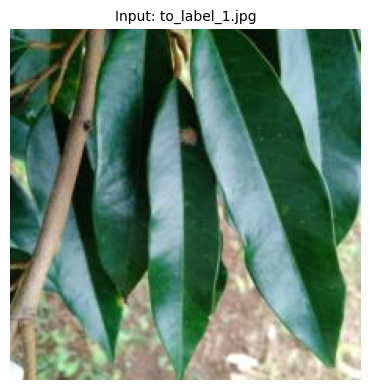

In [ ]:
# ─── CẤU HÌNH ─────────────────────────────────────────────────────────────────
IMAGE_PATH = r'notebooks/data/raw/train/ALGAL_LEAF_SPOT/to_label_1.jpg'  # <-- đổi path tại đây
SEG_VERSION = 'v3'   # 'v1' | 'v2' | 'v3'
# ──────────────────────────────────────────────────────────────────────────────

img_path_abs = IMAGE_PATH if os.path.isabs(IMAGE_PATH) else os.path.join(proj_root, IMAGE_PATH)
assert os.path.exists(img_path_abs), f'Không tìm thấy ảnh: {img_path_abs}'

CLASS_NAMES = [
    'ALGAL_LEAF_SPOT',
    'ALLOCARIDARA_ATTACK',
    'HEALTHY_LEAF',
    'LEAF_BLIGHT',
    'PHOMOPSIS_LEAF_SPOT',
]
NUM_CLASSES = len(CLASS_NAMES)

orig_img = Image.open(img_path_abs).convert('RGB')
orig_arr = np.array(orig_img.resize((224, 224)))

plt.figure(figsize=(4, 4))
plt.imshow(orig_arr)
plt.title(f'Input: {os.path.basename(img_path_abs)}', fontsize=10)
plt.axis('off')
plt.tight_layout()
plt.show()

## 1) Classification — EfficientNet-B0

In [ ]:
cls_model = EfficientNetClassifier(num_classes=NUM_CLASSES, backbone='efficientnet_b0', pretrained=False)

ckpt_candidates = glob.glob(os.path.join(proj_root, 'notebooks', 'models', 'classification', 'checkpoints', '*.pth'))
if not ckpt_candidates:
    ckpt_candidates = glob.glob(os.path.join(proj_root, 'models', 'classification', 'checkpoints', '*.pth'))
assert ckpt_candidates, 'Không tìm thấy checkpoint classification. Chạy notebook 02 trước.'

cls_ckpt_path = max(ckpt_candidates, key=os.path.getctime)
cls_ckpt = torch.load(cls_ckpt_path, map_location=device, weights_only=False)
cls_model.load_state_dict(cls_ckpt['model_state_dict'])
cls_model.to(device).eval()
print(f'Classification model loaded: {os.path.basename(cls_ckpt_path)}')

Classification model loaded: best_model.pth


In [ ]:
cls_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

input_tensor = cls_transform(orig_img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = cls_model(input_tensor)
    probs  = torch.softmax(logits, dim=1)[0].cpu().numpy()

pred_idx   = int(np.argmax(probs))
pred_class = CLASS_NAMES[pred_idx]
confidence = float(probs[pred_idx])

print(f'\nPredicted class : {pred_class}')
print(f'Confidence      : {confidence:.4f} ({confidence*100:.1f}%)')
print('\nAll class probabilities:')
for i, (name, p) in enumerate(zip(CLASS_NAMES, probs)):
    bar = '█' * int(p * 30)
    mark = ' ◄' if i == pred_idx else ''
    print(f'  {name:<28} {p:.4f}  {bar}{mark}')


Predicted class : ALGAL_LEAF_SPOT
Confidence      : 0.9929 (99.3%)

All class probabilities:
  ALGAL_LEAF_SPOT              0.9929  █████████████████████████████ ◄
  ALLOCARIDARA_ATTACK          0.0000  
  HEALTHY_LEAF                 0.0004  
  LEAF_BLIGHT                  0.0005  
  PHOMOPSIS_LEAF_SPOT          0.0062  


## 2) GradCAM — Explainability

In [ ]:
target_layer = find_efficientnet_target_layer(cls_model)
gradcam_gen  = GradCAMGenerator(cls_model, target_layer=target_layer, device=device.type)

heatmap, _, _ = gradcam_gen.generate(input_tensor, pred_idx)

heatmap_uint8   = (heatmap * 255).astype(np.uint8)
heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_rgb     = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
gradcam_overlay = cv2.addWeighted(orig_arr, 0.6, heatmap_rgb, 0.4, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig_arr)
axes[0].set_title('Input Image', fontsize=11)
axes[0].axis('off')

axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title('GradCAM Heatmap', fontsize=11)
axes[1].axis('off')

axes[2].imshow(gradcam_overlay)
axes[2].set_title(f'GradCAM Overlay\n{pred_class} ({confidence*100:.1f}%)', fontsize=11)
axes[2].axis('off')

plt.suptitle('GradCAM Explainability', fontsize=13)
plt.tight_layout()
plt.show()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\colormap.cpp:736: error: (-5:Bad argument) cv::ColorMap only supports source images of type CV_8UC1 or CV_8UC3 in function 'cv::colormap::ColorMap::operator ()'


## 3) Segmentation — UNet++ (chọn V1 / V2 / V3)

In [ ]:
SEG_CKPT_MAP = {
    'v1': os.path.join(proj_root, 'notebooks', 'models', 'segmentation',    'checkpoints', 'efficientnet_unet_best.pth'),
    'v2': os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v2', 'checkpoints', 'unetpp_best.pth'),
    'v3': os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v3', 'checkpoints', 'unetpp_v3_best.pth'),
}

seg_ckpt_path = SEG_CKPT_MAP[SEG_VERSION]
assert os.path.exists(seg_ckpt_path), f'Không tìm thấy checkpoint segmentation {SEG_VERSION}: {seg_ckpt_path}'

if SEG_VERSION == 'v1':
    from utils.models import EfficientNetUNet
    seg_model = EfficientNetUNet(num_classes=1, pretrained=False).to(device)
else:
    seg_model = smp.UnetPlusPlus(
        encoder_name='efficientnet-b0',
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation=None,
    ).to(device)

seg_ckpt = torch.load(seg_ckpt_path, map_location=device, weights_only=False)
seg_model.load_state_dict(seg_ckpt['model_state_dict'])
seg_model.eval()
print(f'Segmentation model {SEG_VERSION.upper()} loaded (epoch {seg_ckpt["epoch"]}, val_loss={seg_ckpt["val_loss"]:.4f})')

In [ ]:
seg_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

img_np = np.array(orig_img.resize((224, 224)))
aug    = seg_transform(image=img_np)
seg_input = aug['image'].unsqueeze(0).to(device)

with torch.no_grad():
    seg_out  = seg_model(seg_input)
    seg_prob = torch.sigmoid(seg_out)[0, 0].cpu().numpy()
    seg_mask = (seg_prob > 0.5).astype(np.uint8)

coverage = seg_mask.mean() * 100
print(f'Mask coverage: {coverage:.1f}% of image area')

# Overlay mask lên ảnh gốc
mask_rgb = np.zeros_like(orig_arr)
mask_rgb[:, :, 1] = seg_mask * 255
seg_overlay = cv2.addWeighted(orig_arr, 0.7, mask_rgb, 0.3, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig_arr)
axes[0].set_title('Input Image', fontsize=11)
axes[0].axis('off')

axes[1].imshow(seg_prob, cmap='hot', vmin=0, vmax=1)
axes[1].set_title('Probability Map', fontsize=11)
axes[1].axis('off')

axes[2].imshow(seg_overlay)
axes[2].set_title(f'Segmentation Overlay\nCoverage={coverage:.1f}%', fontsize=11)
axes[2].axis('off')

plt.suptitle(f'Segmentation {SEG_VERSION.upper()}', fontsize=13)
plt.tight_layout()
plt.show()

## 4) Summary Panel — tổng hợp kết quả

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# (1) Ảnh gốc
axes[0].imshow(orig_arr)
axes[0].set_title('Input Image', fontsize=11)
axes[0].axis('off')

# (2) Classification bar chart
colors = ['tomato' if i == pred_idx else 'steelblue' for i in range(NUM_CLASSES)]
short_names = [n.replace('_', '\n') for n in CLASS_NAMES]
axes[1].barh(short_names, probs, color=colors)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Probability')
axes[1].set_title(f'Classification\n{pred_class}\n({confidence*100:.1f}%)', fontsize=10)
axes[1].grid(True, axis='x')
for i, p in enumerate(probs):
    axes[1].text(p + 0.01, i, f'{p:.2f}', va='center', fontsize=8)

# (3) GradCAM overlay
axes[2].imshow(gradcam_overlay)
axes[2].set_title('GradCAM Overlay', fontsize=11)
axes[2].axis('off')

# (4) Segmentation mask
axes[3].imshow(seg_mask, cmap='gray')
axes[3].set_title(f'Seg Mask ({SEG_VERSION.upper()})', fontsize=11)
axes[3].axis('off')

# (5) Overlay tổng hợp: GradCAM + mask contour
contours, _ = cv2.findContours(seg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
combined = gradcam_overlay.copy()
cv2.drawContours(combined, contours, -1, (255, 255, 0), 2)
axes[4].imshow(combined)
axes[4].set_title('GradCAM + Seg Contour', fontsize=11)
axes[4].axis('off')

plt.suptitle(
    f'Full Inference — {os.path.basename(img_path_abs)}\n'
    f'Predicted: {pred_class}  |  Confidence: {confidence*100:.1f}%  |  Mask coverage: {coverage:.1f}%',
    fontsize=12
)
plt.tight_layout()

out_dir = os.path.join(proj_root, 'notebooks', 'outputs', 'inference')
os.makedirs(out_dir, exist_ok=True)
out_name = f'inference_{os.path.splitext(os.path.basename(img_path_abs))[0]}.png'
plt.savefig(os.path.join(out_dir, out_name), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(out_dir, out_name)}')

In [ ]:
print('=' * 50)
print('INFERENCE RESULT')
print('=' * 50)
print(f'  Image      : {os.path.basename(img_path_abs)}')
print(f'  Prediction : {pred_class}')
print(f'  Confidence : {confidence*100:.1f}%')
print(f'  Seg model  : {SEG_VERSION.upper()}')
print(f'  Coverage   : {coverage:.1f}%')
print('=' * 50)